# Modern Portfolio Theory

Modern Portfolio Theory (MPT) is a foundational framework in quantitative finance that provides a systematic approach to portfolio construction and risk management. Developed by Harry Markowitz in 1952, MPT formalizes the idea that investors should not evaluate assets in isolation, but rather consider how assets interact with one another within a portfolio.

The core principle of MPT is diversification: by combining assets with different risk and return characteristics — particularly those with low or negative correlations — investors can reduce overall portfolio risk without necessarily sacrificing expected return.

In this notebook, we will:

- Compute expected returns and covariance matrices
- Construct portfolios and evaluate their risk-return profiles
- Generate and visualize the Efficient Frontier
- Identify optimal portfolios such as the minimum variance portfolio and the maximum Sharpe ratio portfolio

Through both theoretical explanation and practical implementation in Python, this notebook demonstrates how Modern Portfolio Theory transforms portfolio selection into a quantitative optimization problem.


Import the libraries

In [1]:
import pandas as pd
import numpy as np
import math
import yfinance as yf
from matplotlib import pyplot as plt
import plotly.express as px

#### Step 1: Import the data

For our analysis of MPT, we will be selecting the following stocks that constitute our portfolio. Feel free to change them as you wish.

In [3]:
# Initialize parameters
risk_free_rate = 0.02  # Risk-free rate (e.g., 2%)
market_return = 0.08    # Expected market return (e.g., 8%)
stock_tickers = ['AAPL', 'AMZN', 'MSFT', 'TSLA', 'GOOGL', 'META']  # List of stock tickers
index_ticker = '^GSPC'  # S&P 500 index ticker
start_date = '2020-01-01'
end_date = '2025-01-01'

In [6]:
# Add the index ticker to the list of stock tickers
stock_tickers.append(index_ticker)
stocks_df = yf.download(stock_tickers, start=start_date, end=end_date)['Close']
stocks_df = stocks_df.dropna()

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_46397/4136823213.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks_df = yf.download(stock_tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  7 of 7 completed


#### Step 2: Compute the Daily Returns and Covariance Matrix

In [7]:
returns_df = stocks_df.pct_change().dropna()
cov_matrix = returns_df.cov() * 252  # Annualized covariance matrix

#### Step 3: Measuring Risk for an Asset and a Portfolio

Portfolio risk is measured using the variance–covariance framework. Rather than looking at assets individually, we evaluate how their returns move together and how their combined weights influence total risk.

The overall procedure is as follows:

1. Compute the covariance matrix of asset returns.
2. Annualize the covariance matrix by multiplying by 252 (the approximate number of trading days in a year).
3. Calculate portfolio variance using the asset weight vector.
4. Take the square root of the variance to obtain portfolio volatility (standard deviation).


##### 1️⃣ Covariance Matrix

The covariance matrix captures how asset returns move relative to one another. If $\Sigma_{daily}$ represents the daily covariance matrix of returns, then the annualized covariance matrix is:

$$
\Sigma_{annual} = 252 \times \Sigma_{daily}
$$

The factor 252 is used because there are approximately 252 trading days in a year, allowing us to scale daily risk to an annual measure.


##### 2️⃣ Portfolio Variance

Let:
- $\mathbf{w}$ = vector of portfolio weights  
- $\Sigma$ = annualized covariance matrix  

The portfolio variance is given by:

$$
\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}
$$

This formula incorporates both:
- Individual asset risk (variances on the diagonal)
- Cross-asset relationships (covariances off-diagonal)

##### 3️⃣ Portfolio Volatility

The portfolio’s volatility (standard deviation) is simply the square root of its variance:

$$
\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}
$$

This value represents the total annualized risk of the portfolio and is the standard measure of risk used in Modern Portfolio Theory.

In [15]:
def modern_portfolio_theory_computation(stocks_df):
  portfolio_rets = []
  portfolio_vol = []
  portfolio_weights = []
  num_stocks = len(stocks_df.columns)
  num_portfolios = 10000
  
  df = stocks_df.copy()
  cov_matrix = df.pct_change().cov() * 252  # Annualized covariance matrix
  # Compute the individual stock returns
  individual_rets = df.pct_change().mean()
  
  for port in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(num_stocks) # Random weights
    weights /= np.sum(weights) # Normalize to sum to 1
    portfolio_weights.append(weights)
    
    # Computing the returns
    returns = np.dot(weights, individual_rets) * 252
    portfolio_rets.append(returns)
    
    # Computing the volatility
    volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    portfolio_vol.append(volatility)
    
  portfolio_df = pd.DataFrame({'Returns': portfolio_rets, 'Volatility': portfolio_vol})
  for i, stock in enumerate(stocks_df.columns):
    portfolio_df[stock + ' Weight'] = [weight[i] for weight in portfolio_weights]
    
  return portfolio_df

In [16]:
# Running the MPT computation
equities = stocks_df[[ticker for ticker in stock_tickers if ticker != index_ticker]]
portfolio_df = modern_portfolio_theory_computation(equities)
portfolio_df.head()


,Returns,Volatility,AAPL Weight,AMZN Weight,MSFT Weight,TSLA Weight,GOOGL Weight,META Weight
0,0.328914,0.306187,0.283664,0.291416,0.201185,0.136982,0.072764,0.013990
1,0.302276,0.301986,0.090733,0.279025,0.140894,0.092670,0.336536,0.060142
2,0.354088,0.314006,0.289177,0.170245,0.206787,0.174430,0.080013,0.079348
3,0.459759,0.391667,0.117710,0.197013,0.028237,0.385298,0.060431,0.211312
4,0.440485,0.368446,0.067264,0.001333,0.274127,0.359148,0.223390,0.074737


#### Step 4: Generate the Efficient Frontier

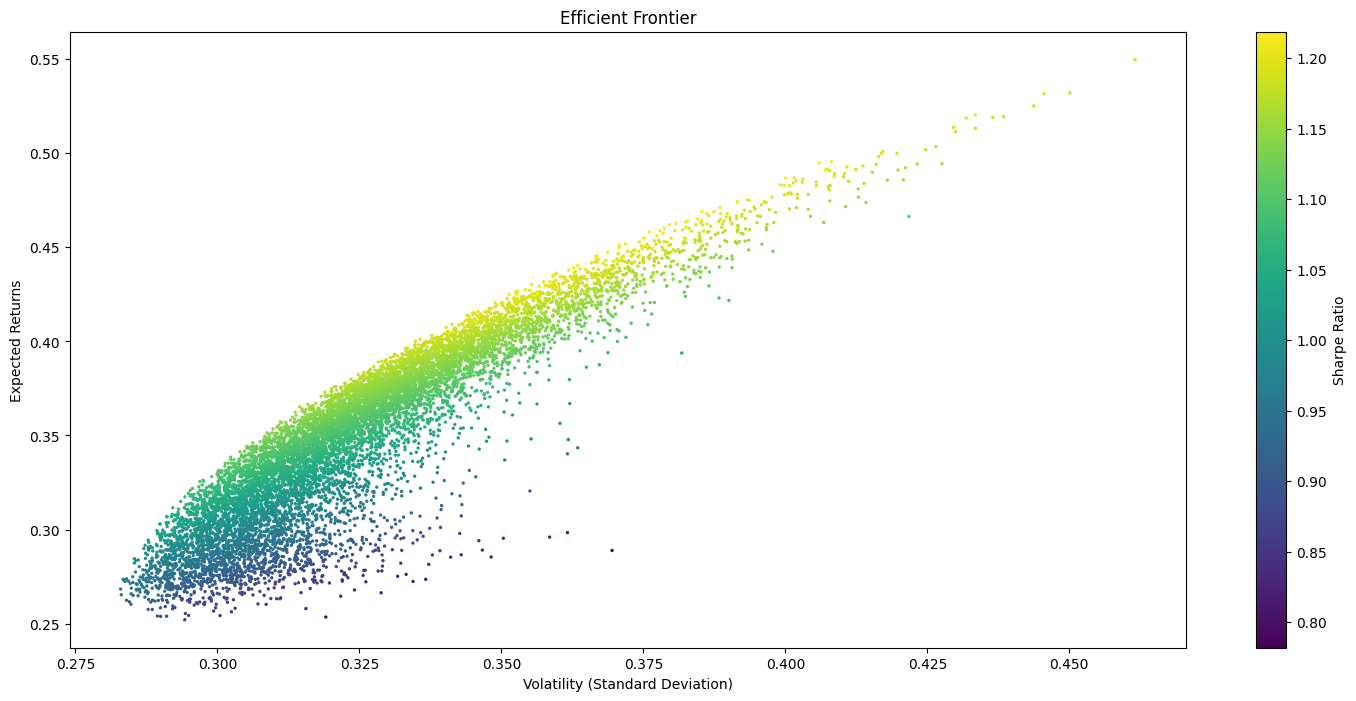

In [21]:
# Plot the efficient frontier
plt.figure(figsize=(18, 8))
plt.scatter(portfolio_df['Volatility'], portfolio_df['Returns'], c=portfolio_df['Returns'] / portfolio_df['Volatility'], marker='o', s=2, cmap='viridis')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Returns')
plt.colorbar(label='Sharpe Ratio')
plt.title('Efficient Frontier')
plt.show()

#### Step 5: Identify Optimal Portfolios 

For this, we will look at minimum variance portfolio and the maximum Sharpe ratio portfolio. In addition, we will also plot the CAPM line on the chart

In [24]:
# Minimum Volatility Portfolio
min_vol_port = portfolio_df.loc[portfolio_df['Volatility'].idxmin()]
print(f"Minimum Volatility Portfolio: \n{min_vol_port}")

Minimum Volatility Portfolio: 
Returns         0.268393
Volatility      0.282956
AAPL Weight     0.316963
AMZN Weight     0.050857
MSFT Weight     0.340596
TSLA Weight     0.003375
GOOGL Weight    0.277232
META Weight     0.010976
Name: 8450, dtype: float64


In [27]:
# Finding the maximum Sharpe Ratio Portfolio
portfolio_df['Sharpe Ratio'] = (portfolio_df['Returns'] - risk_free_rate)/ portfolio_df['Volatility']
max_sharpe_port = portfolio_df.loc[portfolio_df['Sharpe Ratio'].idxmax()]
print(f"\nMaximum Sharpe Ratio Portfolio: \n{max_sharpe_port}")


Maximum Sharpe Ratio Portfolio: 
Returns         0.494785
Volatility      0.405929
AAPL Weight     0.275643
AMZN Weight     0.012446
MSFT Weight     0.020465
TSLA Weight     0.447580
GOOGL Weight    0.169794
META Weight     0.074072
Sharpe Ratio    1.169625
Name: 6578, dtype: float64


#### Step 6: Plotting the Minimum Volatility Portfolio and Sharpe-Ratio Optimal Portfolio

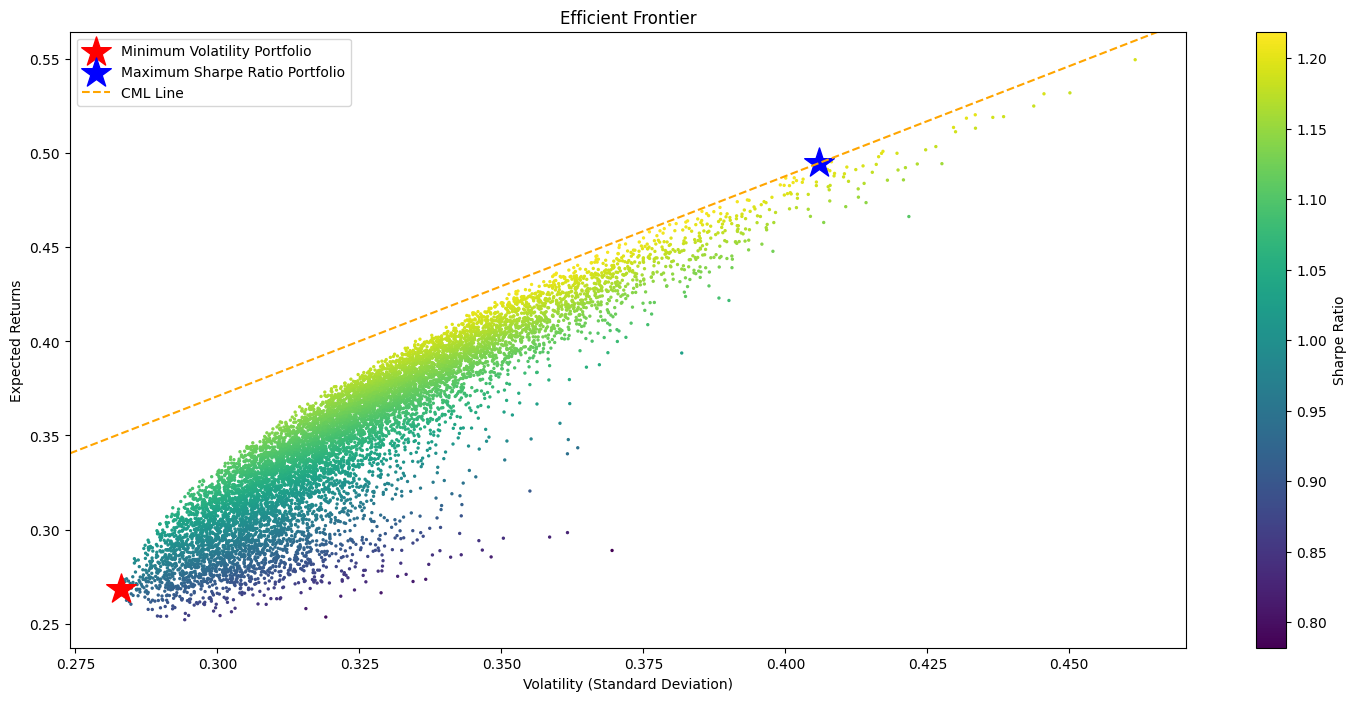


Minimum Volatility Portfolio: 
Volatility: 0.2830, Returns: 0.2684. Sharpe Ratio: 0.8778

Maximum Sharpe Ratio Portfolio: 
Volatility: 0.4059, Returns: 0.4948. Sharpe Ratio: 1.1696


In [44]:
plt.figure(figsize=(18, 8))

# Efficient Frontier
sc = plt.scatter(portfolio_df['Volatility'], portfolio_df['Returns'], c=portfolio_df['Returns'] / portfolio_df['Volatility'], marker='o', s=2, cmap='viridis')

# Minimum Volatility Portfolio
plt.scatter(min_vol_port['Volatility'], min_vol_port['Returns'], color='red', marker='*', s=500, label='Minimum Volatility Portfolio')

# Maximum Sharpe Ratio Portfolio
plt.scatter(max_sharpe_port['Volatility'], max_sharpe_port['Returns'], color='blue', marker='*', s=500, label='Maximum Sharpe Ratio Portfolio')

# --- Capture axis limits BEFORE plotting CML ---
x_limits = plt.xlim()
y_limits = plt.ylim()

# CML slope
cml_slope = (max_sharpe_port['Returns'] - risk_free_rate) / max_sharpe_port['Volatility']

# Use existing x-axis range only
cml_x = np.linspace(x_limits[0], x_limits[1], 100)
cml_y = risk_free_rate + cml_slope * cml_x

plt.plot(cml_x, cml_y, color='orange', linestyle='--', label='CML Line')

# Restore original limits (prevents resizing)
plt.xlim(x_limits)
plt.ylim(y_limits)

plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Returns')
plt.legend()
plt.colorbar(sc, label='Sharpe Ratio')
plt.title('Efficient Frontier')
plt.show()

# Print the portfolios
min_vol_port_volatility = min_vol_port['Volatility']
min_vol_port_returns = min_vol_port['Returns']
min_vol_port_sharpe = (min_vol_port['Returns'] - risk_free_rate)/ min_vol_port['Volatility']

max_sharpe_port_volatility = max_sharpe_port['Volatility']
max_sharpe_port_returns = max_sharpe_port['Returns']
max_sharpe_port_sharpe = (max_sharpe_port['Returns'] - risk_free_rate)/ max_sharpe_port['Volatility']

print(f"\nMinimum Volatility Portfolio: \nVolatility: {min_vol_port_volatility:.4f}, Returns: {min_vol_port_returns:.4f}. Sharpe Ratio: {min_vol_port_sharpe:.4f}")
print(f"\nMaximum Sharpe Ratio Portfolio: \nVolatility: {max_sharpe_port_volatility:.4f}, Returns: {max_sharpe_port_returns:.4f}. Sharpe Ratio: {max_sharpe_port_sharpe:.4f}")